## L'optimisation financière: La diversification
### Import des librairies
Si nécessaire, télécharge les librairies à l'aide de :
`pip install numpy pandas matplotlib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n_jours = 252
# Paramètres des 3 actifs fictifs (mu = rend. moyen, sigma = volatilité)
actifs = {
"Actif A (stable)": {"mu": 0.0003, "sigma": 0.008},
"Actif B (dynamique)": {"mu": 0.0006, "sigma": 0.020},
"Actif C (cyclique)": {"mu": 0.0002, "sigma": 0.015},
}
# Simulation des rendements journaliers (loi normale)
rendements = pd.DataFrame({
nom: np.random.normal(p["mu"], p["sigma"], n_jours)
for nom, p in actifs.items()
})
# Prix indexés à 100 au départ
prix = (1 + rendements).cumprod() * 100
# Portefeuille diversifié à poids égaux
prix["Portefeuille (1/3 chacun)"] = prix.mean(axis=1)


### Création de graphique

C:\Users\HP\AppData\Local\Temp\ipykernel_23544\2176534795.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


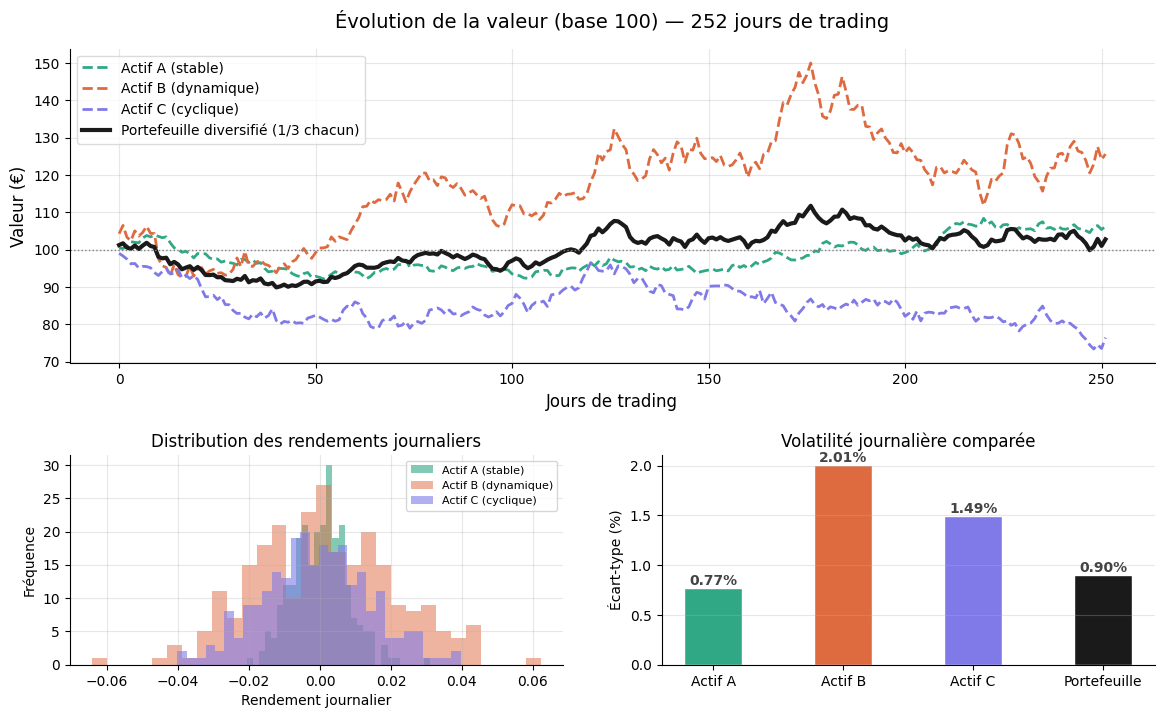

In [3]:
# --- 2. CRÉATION DES GRAPHIQUES ---

# Palette de couleurs 
from matplotlib import gridspec


col_A = '#30a886' # Vert
col_B = '#de6b40' # Orange
col_C = '#807ae8' # Violet
col_Port = '#1a1a1a' # Noir

fig = plt.figure(figsize=(14, 8), facecolor='white')
# Création d'une grille : 2 lignes, 2 colonnes. La ligne du haut est 1.5x plus haute.
gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1], hspace=0.35)

# -- Graphique 1 (Haut) : Évolution de la valeur --
ax1 = plt.subplot(gs[0, :])
ax1.plot(prix.index, prix['Actif A (stable)'], color=col_A, linestyle='--', linewidth=2, label='Actif A (stable)')
ax1.plot(prix.index, prix['Actif B (dynamique)'], color=col_B, linestyle='--', linewidth=2, label='Actif B (dynamique)')
ax1.plot(prix.index, prix['Actif C (cyclique)'], color=col_C, linestyle='--', linewidth=2, label='Actif C (cyclique)')
ax1.plot(prix.index, prix['Portefeuille (1/3 chacun)'], color=col_Port, linestyle='-', linewidth=3, label='Portefeuille diversifié (1/3 chacun)')

ax1.axhline(100, color='gray', linestyle=':', linewidth=1) # Ligne de base 100
ax1.set_title("Évolution de la valeur (base 100) — 252 jours de trading", fontsize=14, pad=15)
ax1.set_ylabel("Valeur (€)", fontsize=12)
ax1.set_xlabel("Jours de trading", fontsize=12)
ax1.legend(loc='upper left', frameon=True, edgecolor='lightgray')
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# -- Graphique 2 (Bas Gauche) : Distribution des rendements --
ax2 = plt.subplot(gs[1, 0])
ax2.hist(rendements['Actif A (stable)'], bins=30, alpha=0.6, color=col_A, label='Actif A (stable)')
ax2.hist(rendements['Actif B (dynamique)'], bins=30, alpha=0.5, color=col_B, label='Actif B (dynamique)')
ax2.hist(rendements['Actif C (cyclique)'], bins=30, alpha=0.6, color=col_C, label='Actif C (cyclique)')

ax2.set_title("Distribution des rendements journaliers", fontsize=12)
ax2.set_ylabel("Fréquence", fontsize=10)
ax2.set_xlabel("Rendement journalier", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# -- Graphique 3 (Bas Droite) : Volatilité comparée --
ax3 = plt.subplot(gs[1, 1])
# Calcul de l'écart-type en pourcentage
volatilites = rendements.std() * 100
noms_barres = ['Actif A', 'Actif B', 'Actif C', 'Portefeuille']
valeurs_barres = [
    volatilites['Actif A (stable)'],
    volatilites['Actif B (dynamique)'],
    volatilites['Actif C (cyclique)'],
    prix['Portefeuille (1/3 chacun)'].pct_change().std() * 100
]
couleurs_barres = [col_A, col_B, col_C, col_Port]

barres = ax3.bar(noms_barres, valeurs_barres, color=couleurs_barres, width=0.45, edgecolor='white')

ax3.set_title("Volatilité journalière comparée", fontsize=12)
ax3.set_ylabel("Écart-type (%)", fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Ajout des valeurs au-dessus des barres
for barre in barres:
    hauteur = barre.get_height()
    ax3.text(barre.get_x() + barre.get_width() / 2., hauteur,
             f'{hauteur:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444444')

# Affichage du résultat
plt.tight_layout()
plt.show()